# Malaria model ranking

Multi-criteria ranking of malaria scam fits. Loads per-task summary CSVs
from a `scam_fits` run, lets you pick which metrics to rank on, runs
Kendall τ on the chosen metrics, then Borda / TOPSIS / Pareto / pairwise
dominance, and surfaces a winners-by-method comparison.

Mirrors `dh_final_diagnostics.ipynb` from idd-tc-mortality.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from idd_forecast_mbp.select.model_selection import (
    CONFIG_COLS,
    DEFAULT_METRICS,
    NO_FE_METRICS,
    CALIBRATION_METRICS,
    kendall_tau_heatmap,
    borda_rank,
    topsis_rank,
    pareto_frontier,
    pairwise_dominance_summary,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
pd.options.display.max_columns = 80
pd.options.display.width = 160

## Paths

Edit `FIT_OUTPUT_DIR` to point at the scam_fits run you want to rank.
Each task writes one `*summary*.csv` in this dir; the load cell
concatenates them.

In [2]:
FIT_OUTPUT_DIR = Path(
    '/mnt/team/idd/pub/forecast-mbp/03-modeling_data/malaria/scam_fits/lsae_1285/20260512_v2'
)

assert FIT_OUTPUT_DIR.exists(), f'Missing: {FIT_OUTPUT_DIR}'
summary_files = sorted(FIT_OUTPUT_DIR.glob('*summary*.csv'))
print(f'Found {len(summary_files)} summary CSVs in {FIT_OUTPUT_DIR}')

Found 210 summary CSVs in /mnt/team/idd/pub/forecast-mbp/03-modeling_data/malaria/scam_fits/lsae_1285/20260512_v2


## Load

One row per task. Columns described in `model_selection.py` module docstring.

In [3]:
CALIBRATION_METRICS

[]

metric_df: 210 rows × 25 cols
task_id range: 1 .. 210
duplicate task_ids: 0


,task_id,is_aic,is_bic,is_deviance,is_dev_expl,is_r_sq,is_rmse,is_mae,oos_rmse,oos_mae,oos_r_sq,is_pfpr_rmse,is_pfpr_mae,is_pfpr_r,oos_pfpr_rmse,oos_pfpr_mae,oos_pfpr_r,is_no_fe_aic,is_no_fe_bic,is_no_fe_dev_expl,is_no_fe_r_sq,is_no_fe_rmse,is_no_fe_mae,is_no_fe_pfpr_mae,is_no_fe_pfpr_r
0,1,1.412473e+06,1.413252e+06,2.322035e+06,0.818854,0.818854,2.847173,1.985712,5.615491,4.590519,0.295347,0.080750,0.034013,0.875502,0.178830,0.082469,0.255125,1.735822e+06,1.735864e+06,0.439616,0.439616,5.007753,4.052990,0.081259,0.387688
1,2,1.412234e+06,1.413019e+06,2.320093e+06,0.819006,0.819006,2.845982,1.984020,5.399969,4.451391,0.348398,0.080420,0.033871,0.877103,0.179908,0.084052,0.161549,1.717726e+06,1.717790e+06,0.473932,0.473932,4.852004,3.947641,0.081458,0.310486
2,3,1.412221e+06,1.412995e+06,2.320001e+06,0.819013,0.819013,2.845925,1.983988,5.615517,4.590538,0.295340,0.080431,0.033877,0.877081,0.178830,0.082469,0.255106,1.735822e+06,1.735865e+06,0.439616,0.439616,5.007753,4.052990,0.081259,0.387688
3,4,1.412389e+06,1.413179e+06,2.321342e+06,0.818909,0.818909,2.846747,1.985197,5.375138,4.420396,0.354377,0.080999,0.034095,0.874620,0.181886,0.085145,0.127455,1.717695e+06,1.717759e+06,0.473988,0.473988,4.851741,3.935915,0.081686,0.248302
4,5,1.412474e+06,1.413252e+06,2.322040e+06,0.818854,0.818854,2.847175,1.985715,5.615491,4.590519,0.295347,0.080749,0.034013,0.875504,0.178830,0.082469,0.255125,1.735822e+06,1.735864e+06,0.439616,0.439616,5.007753,4.052989,0.081259,0.387688


Before cull: 210 tasks
After non-finite cull: 210 tasks (0 dropped)


In [19]:
metric_df

,task_id,is_aic,is_bic,is_deviance,is_dev_expl,is_r_sq,is_rmse,is_mae,oos_rmse,oos_mae,oos_r_sq,is_pfpr_rmse,is_pfpr_mae,is_pfpr_r,oos_pfpr_rmse,oos_pfpr_mae,oos_pfpr_r,is_no_fe_aic,is_no_fe_bic,is_no_fe_dev_expl,is_no_fe_r_sq,is_no_fe_rmse,is_no_fe_mae,is_no_fe_pfpr_mae,is_no_fe_pfpr_r
1,2,1.412234e+06,1.413019e+06,2.320093e+06,0.819006,0.819006,2.845982,1.984020,5.399969,4.451391,0.348398,0.080420,0.033871,0.877103,0.179908,0.084052,0.161549,1.717726e+06,1.717790e+06,0.473932,0.473932,4.852004,3.947641,0.081458,0.310486
8,9,1.412226e+06,1.413021e+06,2.320007e+06,0.819013,0.819013,2.845929,1.984643,5.422741,4.474250,0.342891,0.080516,0.033922,0.876788,0.180138,0.084315,0.152739,1.717727e+06,1.717802e+06,0.473932,0.473932,4.852000,3.947739,0.081459,0.310493
22,23,1.411521e+06,1.412326e+06,2.314285e+06,0.819459,0.819459,2.842417,1.985761,5.406422,4.461060,0.346840,0.081869,0.034602,0.872796,0.180094,0.084297,0.153367,1.716425e+06,1.716514e+06,0.476323,0.476323,4.840965,3.937655,0.081372,0.309261
57,58,1.403590e+06,1.404436e+06,2.251032e+06,0.824394,0.824394,2.803304,1.985578,5.399968,4.451391,0.348398,0.096332,0.039830,0.831426,0.179908,0.084052,0.161550,1.717726e+06,1.717790e+06,0.473931,0.473931,4.852004,3.947641,0.081458,0.310486
141,142,1.395998e+06,1.396834e+06,2.192163e+06,0.828986,0.828986,2.766405,1.978163,5.399968,4.451392,0.348398,0.105409,0.043219,0.805556,0.179908,0.084052,0.161550,1.717726e+06,1.717790e+06,0.473931,0.473931,4.852007,3.947644,0.081458,0.310486
148,149,1.395977e+06,1.396822e+06,2.191991e+06,0.828999,0.828999,2.766296,1.977469,5.422741,4.474251,0.342891,0.105281,0.043157,0.806111,0.180138,0.084315,0.152740,1.717728e+06,1.717803e+06,0.473932,0.473932,4.852004,3.947743,0.081459,0.310494


## Pick metrics

Edit `metrics_to_use` — comment / uncomment lines to define the ranking
set. Direction:
- `'lower'`  → smaller is better
- `'higher'` → larger is better

Tip: run the Kendall τ cell first. AIC / BIC / deviance / IS RMSE are
usually τ > 0.95 on the same fits — keeping all four in the rank set
double-counts the same signal. A parsimonious subset is one IS
information criterion + one IS error + one OOS error + one OOS R².

In [29]:
# no OOS,   yes pfpr,   no mae,     yes urban:  30
# no OOS,   yes pfpr,   yes mae,    yes urban:  30
# no OOS,   no pfpr,    no mae,     yes urban:  179 / 109
# no OOS,   no pfpr,    yes mae,    yes urban:  179 / 32 / 109
# yes OOS,  no pfpr,    no mae,     yes urban:  179
# yes OOS,  no pfpr,    yes mae,    yes urban:  179 / 4
# yes OOS,  yes pfpr,    no mae,     yes urban:  30 / 1 / 59
# yes OOS,  yes pfpr,    yes mae,     yes urban:  30 / 1 / 2

metric_use = {
    'oos': True,
    'pfpr': True,
    'mae': True,
}
use_urban = False


metrics_to_use = {
    # ---- In-sample (with fixed effects) ----
    # 'is_aic':        'lower',
    # 'is_bic':        'lower',
    # 'is_deviance':   'lower',
    # 'is_dev_expl':   'higher',
    'is_r_sq':       'higher',
    # 'is_rmse':       'lower',
    'is_mae':        'lower',

    # ---- In-sample PfPR ----
    # 'is_pfpr_rmse':  'lower',
    'is_pfpr_mae':   'lower',
    'is_pfpr_r':     'higher',

    # ---- Out-of-sample ----
    # 'oos_rmse':      'lower',
    'oos_mae':       'lower',
    'oos_r_sq':      'higher',

    # ---- Out-of-sample PfPR ----
    # 'oos_pfpr_rmse': 'lower',
    'oos_pfpr_mae':  'lower',
    'oos_pfpr_r':    'higher',

    # ---- No-FE metrics ----
    # 'is_no_fe_aic':  'lower',
    # 'is_no_fe_bic':  'lower',
    # 'is_no_fe_dev_expl': 'higher',
    'is_no_fe_r_sq': 'higher',
    # 'is_no_fe_rmse': 'lower',
    'is_no_fe_mae':  'lower',
    'is_no_fe_pfpr_mae':   'lower',
    'is_no_fe_pfpr_r':     'higher',
}

# If any key in metric_use is false, remove all metrics that contain the key
# e.g. if metric_use['oos'] is False, remove all metrics that contain 'oos'
for k, use in metric_use.items():
    if not use:
        metrics_to_use = {m: d for m, d in metrics_to_use.items() if k not in m}




df = pd.concat(
    [pd.read_csv(p) for p in summary_files],
    ignore_index=True,
)

if not use_urban:
    # Filter out all rows where 'urban' is in the formula, since we know those models are bad:
    urban_mask = df['formula_text'].str.contains('urban', case=False, na=False)
    df = df[~urban_mask].copy()

metric_df = df[CONFIG_COLS + list(DEFAULT_METRICS.keys()) + list(NO_FE_METRICS.keys())]

metric_df.head()

rank_cols = [c for c in DEFAULT_METRICS if c in metric_df.columns]
finite_mask = np.isfinite(metric_df[rank_cols].to_numpy()).all(axis=1)
n_failed = int((~finite_mask).sum())
metric_df = metric_df[finite_mask].copy()

# Performance gates — uncomment to apply:
print(metric_df['oos_pfpr_r'].describe())
print(metric_df['oos_mae'].describe())
metric_df = metric_df[metric_df['oos_pfpr_r'] > 0.15].copy()
metric_df = metric_df[metric_df['oos_mae']    < 4.5 ].copy()
# print(f'After performance gates: {len(metric_df):,} tasks')


metrics_present = {k: v for k, v in metrics_to_use.items() if k in metric_df.columns}
calib_present   = [c for c in CALIBRATION_METRICS if c in metric_df.columns]

print(f'Active rank metrics ({len(metrics_present)}):')
for m, d in metrics_present.items():
    print(f'  {m:18s}  {d}')

missing = [k for k in metrics_to_use if k not in metric_df.columns]
if missing:
    print(f'\n[note] {len(missing)} requested metrics not in metric_df (skipped): {missing}')

count    30.000000
mean      0.191377
std       0.046882
min       0.094676
25%       0.164716
50%       0.191787
75%       0.242138
max       0.255126
Name: oos_pfpr_r, dtype: float64
count    30.000000
mean      4.672016
std       0.053141
min       4.590519
25%       4.622946
50%       4.685567
75%       4.706206
max       4.764458
Name: oos_mae, dtype: float64
Active rank metrics (12):
  is_r_sq             higher
  is_mae              lower
  is_pfpr_mae         lower
  is_pfpr_r           higher
  oos_mae             lower
  oos_r_sq            higher
  oos_pfpr_mae        lower
  oos_pfpr_r          higher
  is_no_fe_r_sq       higher
  is_no_fe_mae        lower
  is_no_fe_pfpr_mae   lower
  is_no_fe_pfpr_r     higher


In [24]:
metric_df

,task_id,is_aic,is_bic,is_deviance,is_dev_expl,is_r_sq,is_rmse,is_mae,oos_rmse,oos_mae,oos_r_sq,is_pfpr_rmse,is_pfpr_mae,is_pfpr_r,oos_pfpr_rmse,oos_pfpr_mae,oos_pfpr_r,is_no_fe_aic,is_no_fe_bic,is_no_fe_dev_expl,is_no_fe_r_sq,is_no_fe_rmse,is_no_fe_mae,is_no_fe_pfpr_mae,is_no_fe_pfpr_r


## Kendall τ — metric correlation

Rank correlation between each pair of selected metrics. Tightly correlated
metrics (high τ) add no independent ranking information. Drop redundant
ones from `metrics_to_use` above and re-run.

In [7]:
var = 'oos_pfpr_r'
row = df[df[var] == df[var].max()]
print(f'Best by {var}:')
display(row[CONFIG_COLS + [var]])
print(row['formula_text'].values[0])

Best by oos_pfpr_r:


,task_id,oos_pfpr_r
209,210,0.268795


logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 6, bs = "mpd") + s(gdppc_mean, k = 6, bs = "mpd") + s(weighted_100m_urban_threshold_1500.0_simple_mean, k = 6, bs = "mpd") + s(precipitation_days, k = 6, bs = "cv") + s(relative_humidity, k = 6, bs = "mpi") + logit_malaria_suitability + A0_af


In [8]:
print(df[df['is_r_sq'] == df['is_r_sq'].max()]['formula_text'].values[0])

logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 6, bs = "mpd") + s(gdppc_mean, k = 6, bs = "mpd") + weighted_100m_urban_threshold_1500.0_simple_mean + s(total_precipitation, k = 6, bs = "mpi") + s(relative_humidity, k = 6, bs = "mpi") + logit_malaria_suitability + A0_af


Kendall τ on 6 tasks × 12 metrics


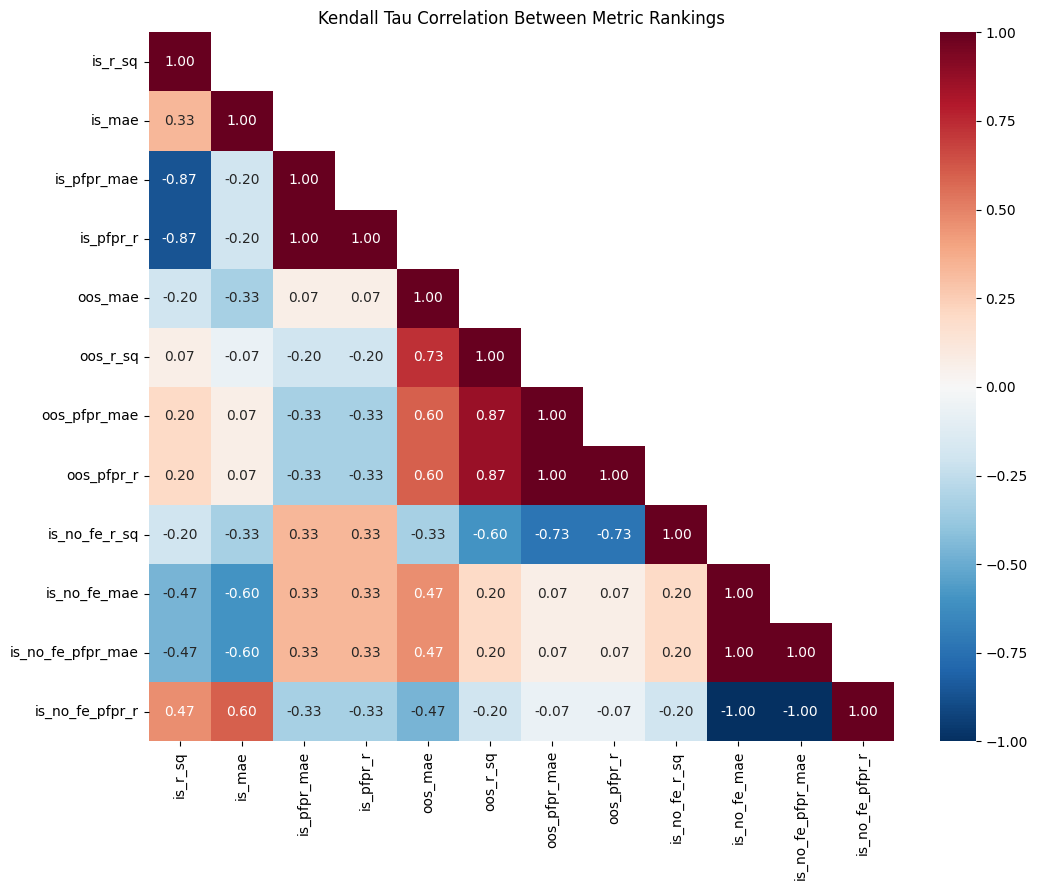


=== Metric Agreement Analysis ===
Average pairwise Kendall tau: -0.006
Pairs with negative correlation: 32
Low agreement. Flat top tier may be aggregation artifact (metric cancellation).


In [9]:
print(f'Kendall τ on {len(metric_df):,} tasks × {len(metrics_present)} metrics')
tau_df = kendall_tau_heatmap(metric_df, metrics_present, calib_present, figsize=(11, 9))
plt.show()

## Borda count

Sum-of-ranks across metrics, with an auto-detected elbow / cutpoint for
where the top tier ends.

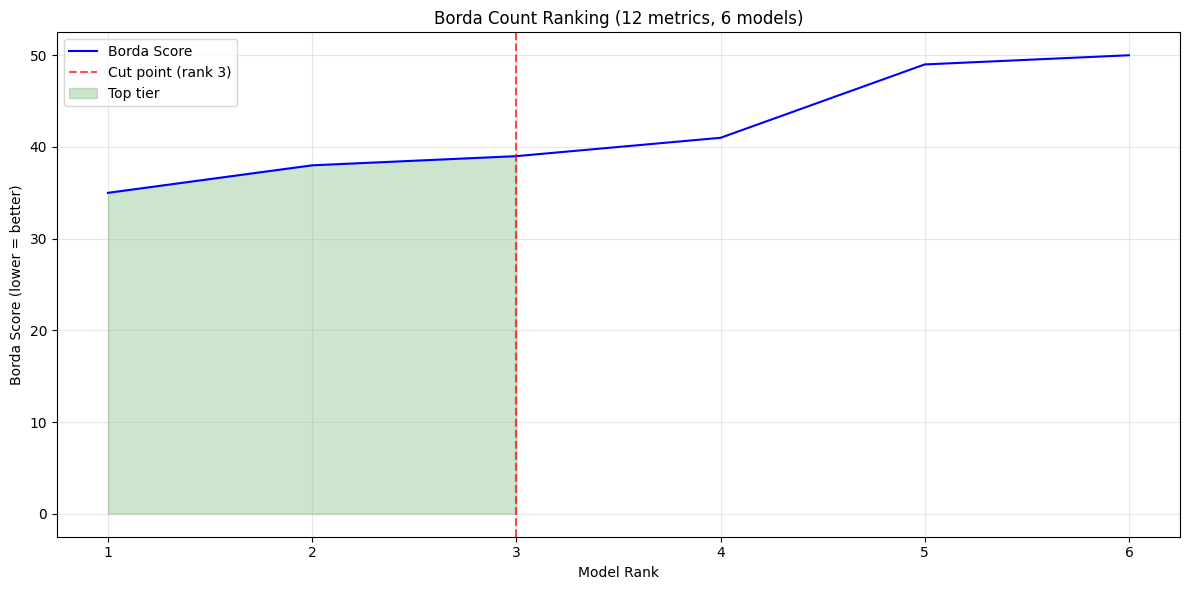


=== Borda Count Summary ===
Total models: 6
Metrics used: 12
Suggested cutpoint: rank 3 (top 3 models)
Top tier Borda range: 35.0 - 39.0
Bottom tier starts at: 41.0


,task_id,is_aic,is_bic,is_deviance,is_dev_expl,is_r_sq,is_rmse,is_mae,oos_rmse,oos_mae,oos_r_sq,is_pfpr_rmse,is_pfpr_mae,is_pfpr_r,oos_pfpr_rmse,oos_pfpr_mae,oos_pfpr_r,is_no_fe_aic,is_no_fe_bic,is_no_fe_dev_expl,is_no_fe_r_sq,is_no_fe_rmse,is_no_fe_mae,is_no_fe_pfpr_mae,is_no_fe_pfpr_r,borda_score,borda_rank
0,2,1.412234e+06,1.413019e+06,2.320093e+06,0.819006,0.819006,2.845982,1.984020,5.399969,4.451391,0.348398,0.080420,0.033871,0.877103,0.179908,0.084052,0.161549,1.717726e+06,1.717790e+06,0.473932,0.473932,4.852004,3.947641,0.081458,0.310486,35.0,1.0
1,58,1.403590e+06,1.404436e+06,2.251032e+06,0.824394,0.824394,2.803304,1.985578,5.399968,4.451391,0.348398,0.096332,0.039830,0.831426,0.179908,0.084052,0.161550,1.717726e+06,1.717790e+06,0.473931,0.473931,4.852004,3.947641,0.081458,0.310486,38.0,2.0
2,142,1.395998e+06,1.396834e+06,2.192163e+06,0.828986,0.828986,2.766405,1.978163,5.399968,4.451392,0.348398,0.105409,0.043219,0.805556,0.179908,0.084052,0.161550,1.717726e+06,1.717790e+06,0.473931,0.473931,4.852007,3.947644,0.081458,0.310486,39.0,3.0
3,23,1.411521e+06,1.412326e+06,2.314285e+06,0.819459,0.819459,2.842417,1.985761,5.406422,4.461060,0.346840,0.081869,0.034602,0.872796,0.180094,0.084297,0.153367,1.716425e+06,1.716514e+06,0.476323,0.476323,4.840965,3.937655,0.081372,0.309261,41.0,4.0
4,9,1.412226e+06,1.413021e+06,2.320007e+06,0.819013,0.819013,2.845929,1.984643,5.422741,4.474250,0.342891,0.080516,0.033922,0.876788,0.180138,0.084315,0.152739,1.717727e+06,1.717802e+06,0.473932,0.473932,4.852000,3.947739,0.081459,0.310493,49.0,5.0
5,149,1.395977e+06,1.396822e+06,2.191991e+06,0.828999,0.828999,2.766296,1.977469,5.422741,4.474251,0.342891,0.105281,0.043157,0.806111,0.180138,0.084315,0.152740,1.717728e+06,1.717803e+06,0.473932,0.473932,4.852004,3.947743,0.081459,0.310494,50.0,6.0


In [10]:
borda_df, borda_cutpoint = borda_rank(metric_df, metrics_present, calib_present)
borda_df.head(10)

## TOPSIS

Distance-to-ideal scoring with min-max normalisation (equal influence per
metric). `influence` reports per-metric separation power.

In [11]:
topsis_df, influence = topsis_rank(metric_df, metrics_present, calib_present, verbose=True)
topsis_df.head(10)


=== TOPSIS Ranking (normalize=minmax) ===
Models ranked: 6
Metrics used: 12

Top 10 by TOPSIS:
   topsis_rank  topsis_score   is_r_sq    is_mae  is_pfpr_mae  is_pfpr_r   oos_mae
0          1.0      0.553676  0.819006  1.984020     0.033871   0.877103  4.451391
1          2.0      0.539974  0.828986  1.978163     0.043219   0.805556  4.451392
2          3.0      0.516142  0.819459  1.985761     0.034602   0.872796  4.461060
3          4.0      0.514655  0.824394  1.985578     0.039830   0.831426  4.451391
4          5.0      0.369299  0.819013  1.984643     0.033922   0.876788  4.474250
5          6.0      0.366415  0.828999  1.977469     0.043157   0.806111  4.474251

Metric Influence (separation power):
           metric  raw_range  normalized_range  normalized_std   weight  influence
          is_r_sq   0.009993          0.083333        0.036915 0.083333   0.006944
           is_mae   0.008292          0.083333        0.034588 0.083333   0.006944
      is_pfpr_mae   0.009348        

,task_id,is_aic,is_bic,is_deviance,is_dev_expl,is_r_sq,is_rmse,is_mae,oos_rmse,oos_mae,oos_r_sq,is_pfpr_rmse,is_pfpr_mae,is_pfpr_r,oos_pfpr_rmse,oos_pfpr_mae,oos_pfpr_r,is_no_fe_aic,is_no_fe_bic,is_no_fe_dev_expl,is_no_fe_r_sq,is_no_fe_rmse,is_no_fe_mae,is_no_fe_pfpr_mae,is_no_fe_pfpr_r,topsis_score,topsis_rank
0,2,1.412234e+06,1.413019e+06,2.320093e+06,0.819006,0.819006,2.845982,1.984020,5.399969,4.451391,0.348398,0.080420,0.033871,0.877103,0.179908,0.084052,0.161549,1.717726e+06,1.717790e+06,0.473932,0.473932,4.852004,3.947641,0.081458,0.310486,0.553676,1.0
1,142,1.395998e+06,1.396834e+06,2.192163e+06,0.828986,0.828986,2.766405,1.978163,5.399968,4.451392,0.348398,0.105409,0.043219,0.805556,0.179908,0.084052,0.161550,1.717726e+06,1.717790e+06,0.473931,0.473931,4.852007,3.947644,0.081458,0.310486,0.539974,2.0
2,23,1.411521e+06,1.412326e+06,2.314285e+06,0.819459,0.819459,2.842417,1.985761,5.406422,4.461060,0.346840,0.081869,0.034602,0.872796,0.180094,0.084297,0.153367,1.716425e+06,1.716514e+06,0.476323,0.476323,4.840965,3.937655,0.081372,0.309261,0.516142,3.0
3,58,1.403590e+06,1.404436e+06,2.251032e+06,0.824394,0.824394,2.803304,1.985578,5.399968,4.451391,0.348398,0.096332,0.039830,0.831426,0.179908,0.084052,0.161550,1.717726e+06,1.717790e+06,0.473931,0.473931,4.852004,3.947641,0.081458,0.310486,0.514655,4.0
4,9,1.412226e+06,1.413021e+06,2.320007e+06,0.819013,0.819013,2.845929,1.984643,5.422741,4.474250,0.342891,0.080516,0.033922,0.876788,0.180138,0.084315,0.152739,1.717727e+06,1.717802e+06,0.473932,0.473932,4.852000,3.947739,0.081459,0.310493,0.369299,5.0
5,149,1.395977e+06,1.396822e+06,2.191991e+06,0.828999,0.828999,2.766296,1.977469,5.422741,4.474251,0.342891,0.105281,0.043157,0.806111,0.180138,0.084315,0.152740,1.717728e+06,1.717803e+06,0.473932,0.473932,4.852004,3.947743,0.081459,0.310494,0.366415,6.0


## Pareto frontier

Non-dominated set: tasks that no other task strictly beats on every
metric. Large frontiers mean genuine trade-offs across metrics; small
frontiers mean a few tasks dominate the field.

In [12]:
pareto_df = pareto_frontier(metric_df, metrics_present, calib_present)
print(f'\nFrontier size: {len(pareto_df):,} / {len(metric_df):,} '
      f'({100 * len(pareto_df) / len(metric_df):.1f}%)')
pareto_df.head(10)


=== Pareto Frontier ===
Total models: 6
Non-dominated: 6 (100.0%)
Dominated: 0

Frontier size: 6 / 6 (100.0%)


,task_id,is_aic,is_bic,is_deviance,is_dev_expl,is_r_sq,is_rmse,is_mae,oos_rmse,oos_mae,oos_r_sq,is_pfpr_rmse,is_pfpr_mae,is_pfpr_r,oos_pfpr_rmse,oos_pfpr_mae,oos_pfpr_r,is_no_fe_aic,is_no_fe_bic,is_no_fe_dev_expl,is_no_fe_r_sq,is_no_fe_rmse,is_no_fe_mae,is_no_fe_pfpr_mae,is_no_fe_pfpr_r
1,2,1.412234e+06,1.413019e+06,2.320093e+06,0.819006,0.819006,2.845982,1.984020,5.399969,4.451391,0.348398,0.080420,0.033871,0.877103,0.179908,0.084052,0.161549,1.717726e+06,1.717790e+06,0.473932,0.473932,4.852004,3.947641,0.081458,0.310486
8,9,1.412226e+06,1.413021e+06,2.320007e+06,0.819013,0.819013,2.845929,1.984643,5.422741,4.474250,0.342891,0.080516,0.033922,0.876788,0.180138,0.084315,0.152739,1.717727e+06,1.717802e+06,0.473932,0.473932,4.852000,3.947739,0.081459,0.310493
22,23,1.411521e+06,1.412326e+06,2.314285e+06,0.819459,0.819459,2.842417,1.985761,5.406422,4.461060,0.346840,0.081869,0.034602,0.872796,0.180094,0.084297,0.153367,1.716425e+06,1.716514e+06,0.476323,0.476323,4.840965,3.937655,0.081372,0.309261
57,58,1.403590e+06,1.404436e+06,2.251032e+06,0.824394,0.824394,2.803304,1.985578,5.399968,4.451391,0.348398,0.096332,0.039830,0.831426,0.179908,0.084052,0.161550,1.717726e+06,1.717790e+06,0.473931,0.473931,4.852004,3.947641,0.081458,0.310486
141,142,1.395998e+06,1.396834e+06,2.192163e+06,0.828986,0.828986,2.766405,1.978163,5.399968,4.451392,0.348398,0.105409,0.043219,0.805556,0.179908,0.084052,0.161550,1.717726e+06,1.717790e+06,0.473931,0.473931,4.852007,3.947644,0.081458,0.310486
148,149,1.395977e+06,1.396822e+06,2.191991e+06,0.828999,0.828999,2.766296,1.977469,5.422741,4.474251,0.342891,0.105281,0.043157,0.806111,0.180138,0.084315,0.152740,1.717728e+06,1.717803e+06,0.473932,0.473932,4.852004,3.947743,0.081459,0.310494


## Pairwise dominance

For each pair (A, B), A beats B if A wins on a majority of metrics.
`dominance_count` = how many tasks each task beats.

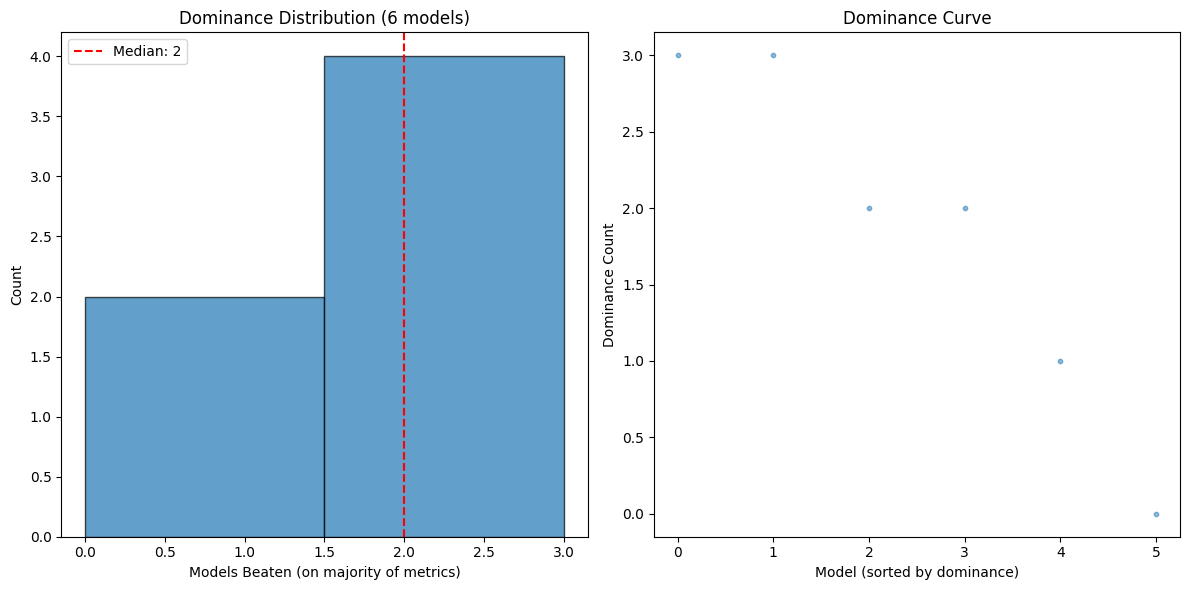


=== Pairwise Dominance Summary ===
Models compared: 6
Metrics used: 12
Max dominance: 3 / 5 models beaten
Median dominance: 2

Top 10 most dominant models:
   dominance_rank  dominance_count  dominance_pct  task_id
0             1.5                3           60.0        2
1             1.5                3           60.0       58
2             3.5                2           40.0      142
3             3.5                2           40.0       23
4             5.0                1           20.0        9
5             6.0                0            0.0      149


,task_id,is_aic,is_bic,is_deviance,is_dev_expl,is_r_sq,is_rmse,is_mae,oos_rmse,oos_mae,oos_r_sq,is_pfpr_rmse,is_pfpr_mae,is_pfpr_r,oos_pfpr_rmse,oos_pfpr_mae,oos_pfpr_r,is_no_fe_aic,is_no_fe_bic,is_no_fe_dev_expl,is_no_fe_r_sq,is_no_fe_rmse,is_no_fe_mae,is_no_fe_pfpr_mae,is_no_fe_pfpr_r,dominance_count,dominance_pct,total_metric_wins,dominance_rank
0,2,1.412234e+06,1.413019e+06,2.320093e+06,0.819006,0.819006,2.845982,1.984020,5.399969,4.451391,0.348398,0.080420,0.033871,0.877103,0.179908,0.084052,0.161549,1.717726e+06,1.717790e+06,0.473932,0.473932,4.852004,3.947641,0.081458,0.310486,3,60.0,37,1.5
1,58,1.403590e+06,1.404436e+06,2.251032e+06,0.824394,0.824394,2.803304,1.985578,5.399968,4.451391,0.348398,0.096332,0.039830,0.831426,0.179908,0.084052,0.161550,1.717726e+06,1.717790e+06,0.473931,0.473931,4.852004,3.947641,0.081458,0.310486,3,60.0,34,1.5
2,142,1.395998e+06,1.396834e+06,2.192163e+06,0.828986,0.828986,2.766405,1.978163,5.399968,4.451392,0.348398,0.105409,0.043219,0.805556,0.179908,0.084052,0.161550,1.717726e+06,1.717790e+06,0.473931,0.473931,4.852007,3.947644,0.081458,0.310486,2,40.0,33,3.5
3,23,1.411521e+06,1.412326e+06,2.314285e+06,0.819459,0.819459,2.842417,1.985761,5.406422,4.461060,0.346840,0.081869,0.034602,0.872796,0.180094,0.084297,0.153367,1.716425e+06,1.716514e+06,0.476323,0.476323,4.840965,3.937655,0.081372,0.309261,2,40.0,31,3.5
4,9,1.412226e+06,1.413021e+06,2.320007e+06,0.819013,0.819013,2.845929,1.984643,5.422741,4.474250,0.342891,0.080516,0.033922,0.876788,0.180138,0.084315,0.152739,1.717727e+06,1.717802e+06,0.473932,0.473932,4.852000,3.947739,0.081459,0.310493,1,20.0,23,5.0
5,149,1.395977e+06,1.396822e+06,2.191991e+06,0.828999,0.828999,2.766296,1.977469,5.422741,4.474251,0.342891,0.105281,0.043157,0.806111,0.180138,0.084315,0.152740,1.717728e+06,1.717803e+06,0.473932,0.473932,4.852004,3.947743,0.081459,0.310494,0,0.0,22,6.0


In [13]:
dominance_df = pairwise_dominance_summary(metric_df, metrics_present, calib_present)
dominance_df.head(10)

## Winners by method

Side-by-side comparison of the top pick from each method on a shared
metric set. Pareto frontier has no canonical order — `pareto_first` is
the first row of the frontier (df order), not a "best" frontier member.

In [14]:
df = df.merge(dominance_df[['task_id', 'dominance_rank']], on='task_id')
df = df.merge(topsis_df[['task_id', 'topsis_rank']], on='task_id')
df = df.merge(borda_df[['task_id', 'borda_rank']], on='task_id')

In [15]:
winners = {
    'borda':              borda_df.iloc[0],
    'topsis':             topsis_df.iloc[0],
    'pareto_first':       pareto_df.iloc[0],
    'pairwise_dominance': dominance_df.iloc[0],
}

show_cols = [c for c in CONFIG_COLS if c in metric_df.columns] +  [k for k in metrics_present.keys()] + ['is_aic', 'is_bic', 'is_dev_expl', 
    'oos_rmse', 'oos_mae']
show_cols = [c for c in show_cols if c in metric_df.columns]

winners_df = pd.DataFrame({k: w[show_cols] for k, w in winners.items()}).T
winners_df['selection_method'] = winners_df.index   # capture here
winners_df = winners_df.merge(dominance_df[['task_id', 'dominance_rank']], on='task_id')
winners_df = winners_df.merge(topsis_df[['task_id', 'topsis_rank']], on='task_id')
winners_df = winners_df.merge(borda_df[['task_id', 'borda_rank']], on='task_id')
winners_df = winners_df.set_index('selection_method')
# make the rank columns more visible by putting them up front:
rank_cols = ['borda_rank', 'topsis_rank', 'dominance_rank']
other_cols = [c for c in winners_df.columns if c not in rank_cols]
winners_df = winners_df[rank_cols + other_cols]
winners_df

,borda_rank,topsis_rank,dominance_rank,task_id,is_r_sq,is_mae,is_pfpr_mae,is_pfpr_r,oos_mae,oos_mae,oos_r_sq,oos_pfpr_mae,oos_pfpr_r,is_no_fe_r_sq,is_no_fe_mae,is_no_fe_pfpr_mae,is_no_fe_pfpr_r,is_aic,is_bic,is_dev_expl,oos_rmse,oos_mae,oos_mae
selection_method,,,,,,,,,,,,,,,,,,,,,,,
borda,1.0,1.0,1.5,2.0,0.819006,1.98402,0.033871,0.877103,4.451391,4.451391,0.348398,0.084052,0.161549,0.473932,3.947641,0.081458,0.310486,1.412234e+06,1.413019e+06,0.819006,5.399969,4.451391,4.451391
topsis,1.0,1.0,1.5,2.0,0.819006,1.98402,0.033871,0.877103,4.451391,4.451391,0.348398,0.084052,0.161549,0.473932,3.947641,0.081458,0.310486,1.412234e+06,1.413019e+06,0.819006,5.399969,4.451391,4.451391
pareto_first,1.0,1.0,1.5,2.0,0.819006,1.98402,0.033871,0.877103,4.451391,4.451391,0.348398,0.084052,0.161549,0.473932,3.947641,0.081458,0.310486,1.412234e+06,1.413019e+06,0.819006,5.399969,4.451391,4.451391
pairwise_dominance,1.0,1.0,1.5,2.0,0.819006,1.98402,0.033871,0.877103,4.451391,4.451391,0.348398,0.084052,0.161549,0.473932,3.947641,0.081458,0.310486,1.412234e+06,1.413019e+06,0.819006,5.399969,4.451391,4.451391


In [16]:
task_id = 2
print(f'Borda rank: {borda_df[borda_df['task_id'] == task_id]['borda_rank'].values[0]}')
print(f'Topsis rank: {topsis_df[topsis_df['task_id'] == task_id]['topsis_rank'].values[0]}')
print(f'Dominance rank: {dominance_df[dominance_df['task_id'] == task_id]['dominance_rank'].values[0]}')
print(df[df['task_id'] == task_id]['formula_text'].values[0])

Borda rank: 1.0
Topsis rank: 1.0
Dominance rank: 1.5
logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 6, bs = "mpd") + s(gdppc_mean, k = 6, bs = "mpd") + weighted_1km_urban_threshold_300.0_simple_mean + logit_malaria_suitability + A0_af


In [17]:
# find all task ids that have people_flood_days and humidity in the formula text
task_ids = df[
    df['formula_text'].str.contains('people_flood_days')
]['task_id'].tolist()
df[df['task_id'].isin(task_ids)][show_cols + [c for c in df.columns if 'rank' in c]].sort_values('topsis_rank')

,task_id,is_r_sq,is_mae,is_pfpr_mae,is_pfpr_r,oos_mae,oos_r_sq,oos_pfpr_mae,oos_pfpr_r,is_no_fe_r_sq,is_no_fe_mae,is_no_fe_pfpr_mae,is_no_fe_pfpr_r,is_aic,is_bic,is_dev_expl,oos_rmse,oos_mae,dominance_rank,topsis_rank,borda_rank
2,23,0.819459,1.985761,0.034602,0.872796,4.461060,0.346840,0.084297,0.153367,0.476323,3.937655,0.081372,0.309261,1.411521e+06,1.412326e+06,0.819459,5.406422,4.461060,3.5,3.0,4.0
1,9,0.819013,1.984643,0.033922,0.876788,4.474250,0.342891,0.084315,0.152739,0.473932,3.947739,0.081459,0.310493,1.412226e+06,1.413021e+06,0.819013,5.422741,4.474250,5.0,5.0,5.0
5,149,0.828999,1.977469,0.043157,0.806111,4.474251,0.342891,0.084315,0.152740,0.473932,3.947743,0.081459,0.310494,1.395977e+06,1.396822e+06,0.828999,5.422741,4.474251,6.0,6.0,6.0


In [18]:
# find all task ids that don't have urban in the formula text
task_ids = df[
    ~df['formula_text'].str.contains('urban')
]['task_id'].tolist()
df[df['task_id'].isin(task_ids)][show_cols + [c for c in df.columns if 'rank' in c]].sort_values('topsis_rank')

,task_id,is_r_sq,is_mae,is_pfpr_mae,is_pfpr_r,oos_mae,oos_r_sq,oos_pfpr_mae,oos_pfpr_r,is_no_fe_r_sq,is_no_fe_mae,is_no_fe_pfpr_mae,is_no_fe_pfpr_r,is_aic,is_bic,is_dev_expl,oos_rmse,oos_mae,dominance_rank,topsis_rank,borda_rank
